# Edge Detection and Image Sharpening (Spatial Filters)

This notebook cell implements:
- Grayscale image reading
- Replicate (edge) padding
- 3x3 Laplacian edge extraction
- Laplacian-based sharpening
- Sobel horizontal (Gx), vertical (Gy), and gradient magnitude

In [5]:
%pip install numpy==1.26.4 opencv-python==4.8.1.78 --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import cv2
import numpy as np
print('cv2 version:', cv2.__version__)
print('numpy version:', np.__version__)

cv2 version: 4.8.1
numpy version: 1.26.4


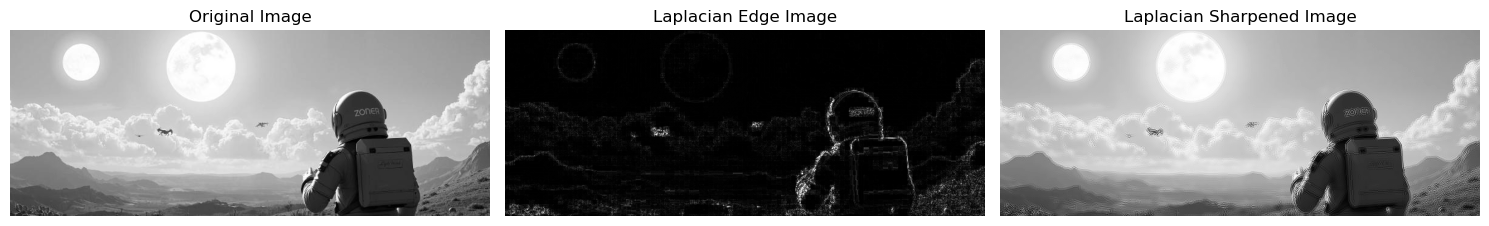

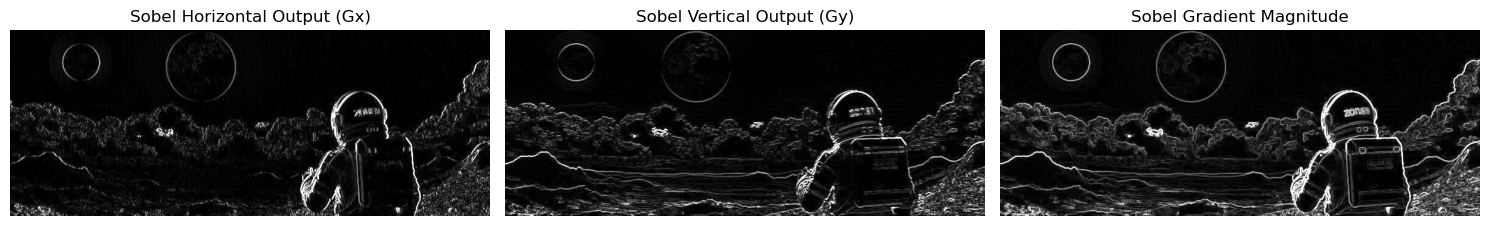

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# a) Read a grayscale image
# Update image_path if you want a specific file. If None, first image in folder is used.
image_path = None

if image_path is None:
    exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")
    candidates = []
    for ext in exts:
        candidates.extend(Path(".").glob(ext))
    if not candidates:
        raise FileNotFoundError("No image found in current folder. Set image_path to a valid image file.")
    image_path = str(sorted(candidates)[0])

img_u8 = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img_u8 is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img = img_u8.astype(np.float32)

# c) 3x3 Laplacian filter with replicate (edge) padding
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

laplacian_response = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=laplacian_kernel, borderType=cv2.BORDER_REPLICATE)

# d) Sharpened image from Laplacian
sharpened = img - laplacian_response

# e) Show original, Laplacian edge, Laplacian sharpened
original_display = img_u8
laplacian_edge_display = cv2.convertScaleAbs(laplacian_response)
sharpened_display = np.clip(sharpened, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_display, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(laplacian_edge_display, cmap="gray")
plt.title("Laplacian Edge Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened_display, cmap="gray")
plt.title("Laplacian Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# f) Sobel horizontal (Gx)
# g) Sobel vertical (Gy)
sobel_gx_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_gy_kernel = np.array([
    [-1, -2, -1],
    [0,  0,  0],
    [1,  2,  1]
], dtype=np.float32)

Gx = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=sobel_gx_kernel, borderType=cv2.BORDER_REPLICATE)
Gy = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=sobel_gy_kernel, borderType=cv2.BORDER_REPLICATE)

# h) Gradient magnitude
grad_mag = cv2.magnitude(Gx, Gy)

# i) Display Sobel outputs and gradient magnitude
Gx_display = cv2.convertScaleAbs(Gx)
Gy_display = cv2.convertScaleAbs(Gy)
grad_display = cv2.convertScaleAbs(grad_mag)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(Gx_display, cmap="gray")
plt.title("Sobel Horizontal Output (Gx)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Gy_display, cmap="gray")
plt.title("Sobel Vertical Output (Gy)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(grad_display, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()